# Credit Card Fraud Detection - Exploratory Data Analysis
**Candidate 307394 | MSc Data Science Dissertation**

This notebook covers:
1. Environment setup & data loading
2. Data quality checks (missing values, duplicates, class labels, data types, outliers)
3. Class imbalance analysis
4. Transaction amount analysis
5. Temporal analysis & concept drift inspection
6. PCA feature analysis
7. Correlation analysis
8. Temporal train-test split
9. Train-test overlap & split integrity check
10. Preprocessing pipeline (StandardScaler)
11. EDA summary for dissertation write-up

---
**Dataset:** ULB/Kaggle European Credit Card Transactions (ULB/Worldline, 2013)

**Source:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**Place `creditcard.csv` in the same folder as this notebook before running.**

**Local path:** Set BASE = ''

## 1. Environment Setup

In [1]:
# Install dependencies if needed (uncomment if running fresh)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
FRAUD_COLOR   = '#D62728'   # red
LEGIT_COLOR   = '#1F77B4'   # blue
NEUTRAL_COLOR = '#7F7F7F'

import pandas, numpy, sklearn
print(f'pandas  : {pandas.__version__}')
print(f'numpy   : {numpy.__version__}')
print(f'sklearn : {sklearn.__version__}')
print('Libraries loaded successfully.')

pandas  : 2.3.3
numpy   : 2.0.2
sklearn : 1.6.1
Libraries loaded successfully.


## 2. Dataset Loading & Overview

In [2]:
# ── Set your path here ────────────────────────────────────────────────────
# Kaggle: BASE = '/kaggle/input/your-dataset-name/'
# Local : BASE = ''
BASE = '/kaggle/input/datasets/gagansinghbhatia/ulbkaggle-credit-card-dataset/'

df = pd.read_csv(BASE + 'creditcard.csv')

print('=== Dataset Shape ===')
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print()
print('=== Column Data Types ===')
print(df.dtypes)
print()
print('=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 284,807  |  Columns: 31

=== Column Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== First 5 Rows ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Data Quality Checks
All checks run on the **raw, unmodified dataset** before any analysis or splitting.
Checks: missing values, duplicate rows, class label integrity, data types, Amount outliers, train-test overlap (Section 9).

In [3]:
print('='*55)
print('DATA QUALITY CHECKS')
print('='*55)

# ── Check 1: Missing values ───────────────────────────────────────────────
print('\n--- Check 1: Missing Values ---')
missing = df.isnull().sum()
n_missing = missing.sum()
if n_missing == 0:
    print('No missing values found across all 31 columns. Dataset is complete.')
else:
    print(f'Missing values found: {n_missing}')
    print(missing[missing > 0])

# ── Check 2: Duplicate rows ───────────────────────────────────────────────
print('\n--- Check 2: Duplicate Rows ---')
n_before     = len(df)
n_duplicates = df.duplicated().sum()
print(f'Total rows before deduplication : {n_before:,}')
print(f'Duplicate rows found            : {n_duplicates:,}')

if n_duplicates > 0:
    dup_class = df[df.duplicated(keep=False)]['Class'].value_counts()
    print(f'Duplicates by class:')
    print(f'  Legitimate (0): {dup_class.get(0, 0):,}')
    print(f'  Fraudulent (1): {dup_class.get(1, 0):,}')
    # Remove duplicates — keep first occurrence
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Duplicates removed. Rows after deduplication: {len(df):,}')
    print('NOTE: Dissertation methodology section updated to note deduplication step.')
else:
    print('No duplicate rows found. Dataset confirmed clean.')

# ── Check 3: Class label integrity ───────────────────────────────────────
print('\n--- Check 3: Class Label Integrity ---')
class_vals = sorted(df['Class'].unique().tolist())
print(f'Unique Class values: {class_vals}')
assert class_vals == [0, 1], f'ERROR: Unexpected class values: {class_vals}'
print('Class is strictly binary: 0=legitimate, 1=fraudulent. Confirmed.')

# ── Check 4: Data type validation ────────────────────────────────────────
print('\n--- Check 4: Data Type Validation ---')
non_numeric = [c for c in df.columns if df[c].dtype not in ['float64','int64']]
if len(non_numeric) == 0:
    print('All 31 columns are numeric (float64 or int64). Confirmed.')
else:
    print(f'Non-numeric columns found: {non_numeric}')

# ── Check 5: Amount outlier summary ──────────────────────────────────────
print('\n--- Check 5: Amount Outlier Summary ---')
q1   = df['Amount'].quantile(0.25)
q3   = df['Amount'].quantile(0.75)
iqr  = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_outliers  = (df['Amount'] > upper_fence).sum()
print(f'Amount Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}')
print(f'Upper fence (Q3 + 1.5*IQR): €{upper_fence:.2f}')
print(f'Outliers above upper fence: {n_outliers:,} ({n_outliers/len(df)*100:.2f}%)')
print(f'Maximum Amount: €{df["Amount"].max():,.2f}')
print('Note: Amount is right-skewed with high-value outliers.')
print('StandardScaler normalisation applied in Section 10 to address this.')

print('\n' + '='*55)
print('ALL DATA QUALITY CHECKS COMPLETE')
print(f'Final dataset for analysis: {len(df):,} rows x {df.shape[1]} columns')
print('='*55)

DATA QUALITY CHECKS

--- Check 1: Missing Values ---
No missing values found across all 31 columns. Dataset is complete.

--- Check 2: Duplicate Rows ---
Total rows before deduplication : 284,807
Duplicate rows found            : 1,081
Duplicates by class:
  Legitimate (0): 1,822
  Fraudulent (1): 32
Duplicates removed. Rows after deduplication: 283,726
NOTE: Dissertation methodology section updated to note deduplication step.

--- Check 3: Class Label Integrity ---
Unique Class values: [0, 1]
Class is strictly binary: 0=legitimate, 1=fraudulent. Confirmed.

--- Check 4: Data Type Validation ---
All 31 columns are numeric (float64 or int64). Confirmed.

--- Check 5: Amount Outlier Summary ---
Amount Q1=5.60  Q3=77.51  IQR=71.91
Upper fence (Q3 + 1.5*IQR): €185.38
Outliers above upper fence: 31,685 (11.17%)
Maximum Amount: €25,691.16
Note: Amount is right-skewed with high-value outliers.
StandardScaler normalisation applied in Section 10 to address this.

ALL DATA QUALITY CHECKS COMPLET

## 4. Class Imbalance Analysis

=== Class Distribution ===
Total transactions :    283,726
Legitimate (0)     :    283,253  (99.8333%)
Fraudulent  (1)    :        473  (0.1667%)
Imbalance ratio    : 599:1

A naive all-legitimate classifier achieves 99.83% accuracy
=> Accuracy is not a valid evaluation metric (Btoush et al., 2023)


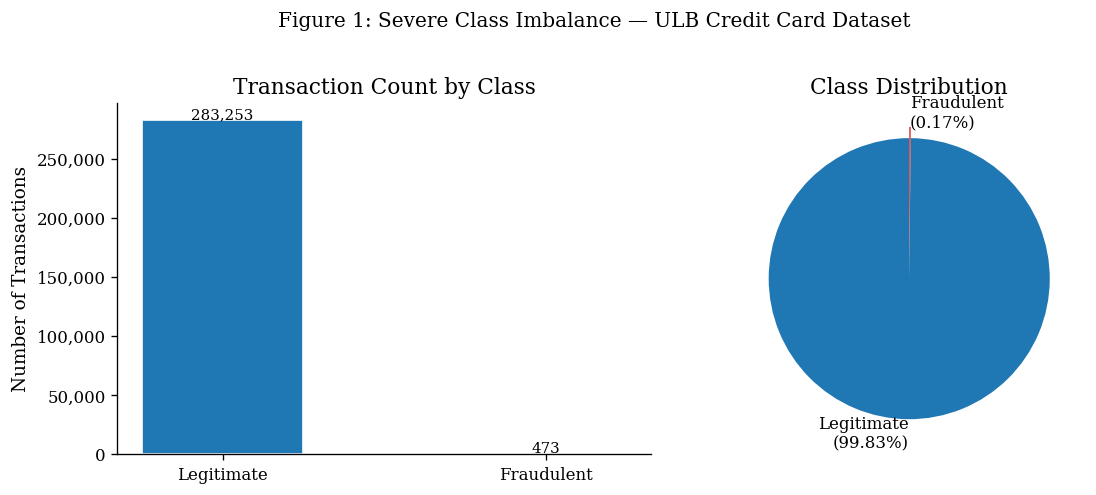

Saved: fig1_class_distribution.png


In [4]:
fraud = df[df['Class'] == 1].copy()
legit = df[df['Class'] == 0].copy()

n_total   = len(df)
n_fraud   = len(fraud)
n_legit   = len(legit)
pct_fraud = n_fraud / n_total * 100

print('=== Class Distribution ===')
print(f'Total transactions : {n_total:>10,}')
print(f'Legitimate (0)     : {n_legit:>10,}  ({100-pct_fraud:.4f}%)')
print(f'Fraudulent  (1)    : {n_fraud:>10,}  ({pct_fraud:.4f}%)')
print(f'Imbalance ratio    : {n_legit/n_fraud:.0f}:1')
print()
print(f'A naive all-legitimate classifier achieves {100-pct_fraud:.2f}% accuracy')
print('=> Accuracy is not a valid evaluation metric (Btoush et al., 2023)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Legitimate', 'Fraudulent'], [n_legit, n_fraud],
            color=[LEGIT_COLOR, FRAUD_COLOR], width=0.5, edgecolor='white')
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, v in enumerate([n_legit, n_fraud]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

axes[1].pie([n_legit, n_fraud],
            labels=[f'Legitimate\n({100-pct_fraud:.2f}%)',
                    f'Fraudulent\n({pct_fraud:.2f}%)'],
            colors=[LEGIT_COLOR, FRAUD_COLOR],
            explode=[0, 0.08], startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Class Distribution')

plt.suptitle('Figure 1: Severe Class Imbalance — ULB Credit Card Dataset', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: fig1_class_distribution.png')

## 5. Transaction Amount Analysis

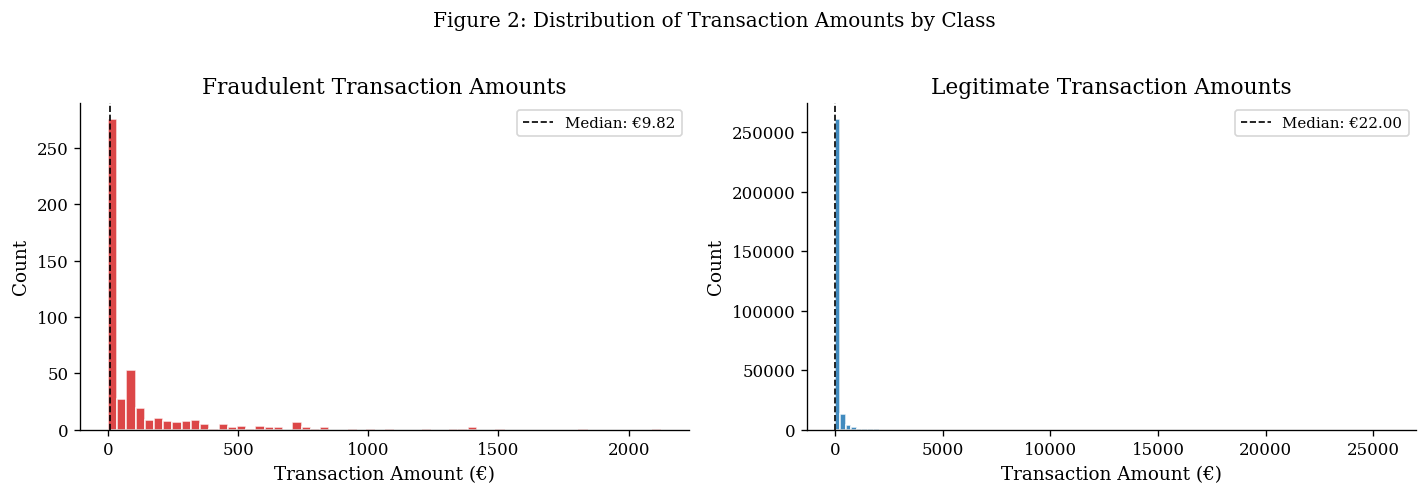

Amount stats — Fraudulent:
count     473.00
mean      123.87
std       260.21
min         0.00
25%         1.00
50%         9.82
75%       105.89
max      2125.87
Name: Amount, dtype: float64

Amount stats — Legitimate:
count    283253.00
mean         88.41
std         250.38
min           0.00
25%           5.67
50%          22.00
75%          77.46
max       25691.16
Name: Amount, dtype: float64


In [5]:
# Amount histograms by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fraud['Amount'], bins=60, color=FRAUD_COLOR, alpha=0.85, edgecolor='white')
axes[0].set_title('Fraudulent Transaction Amounts')
axes[0].set_xlabel('Transaction Amount (€)')
axes[0].set_ylabel('Count')
axes[0].axvline(fraud['Amount'].median(), color='black', linestyle='--', linewidth=1,
                label=f'Median: €{fraud["Amount"].median():.2f}')
axes[0].legend(fontsize=9)

axes[1].hist(legit['Amount'], bins=100, color=LEGIT_COLOR, alpha=0.85, edgecolor='white')
axes[1].set_title('Legitimate Transaction Amounts')
axes[1].set_xlabel('Transaction Amount (€)')
axes[1].set_ylabel('Count')
axes[1].axvline(legit['Amount'].median(), color='black', linestyle='--', linewidth=1,
                label=f'Median: €{legit["Amount"].median():.2f}')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 2: Distribution of Transaction Amounts by Class', y=1.02)
plt.tight_layout()
plt.savefig('fig2_amount_distribution.png', bbox_inches='tight')
plt.show()

print('Amount stats — Fraudulent:')
print(fraud['Amount'].describe().round(2))
print()
print('Amount stats — Legitimate:')
print(legit['Amount'].describe().round(2))

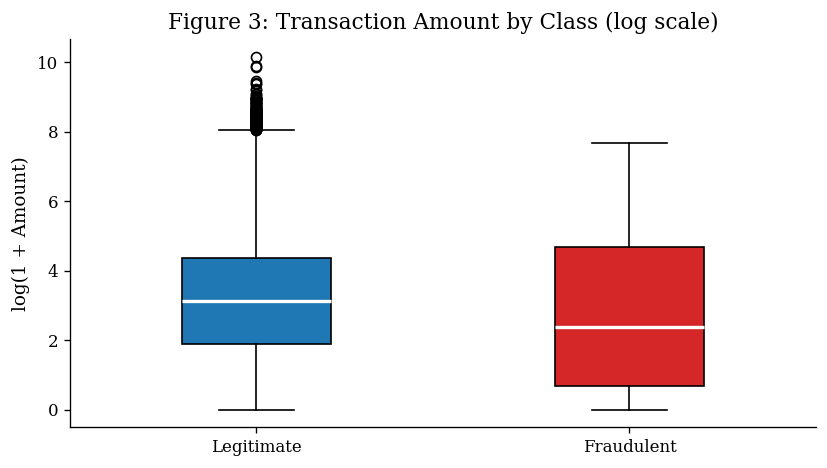

Saved: fig3_amount_boxplot.png


In [6]:
# Log-scale boxplot
df['log_amount'] = np.log1p(df['Amount'])
fraud = df[df['Class'] == 1].copy()
legit = df[df['Class'] == 0].copy()

fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot([legit['log_amount'], fraud['log_amount']],
                patch_artist=True, widths=0.4,
                medianprops={'color': 'white', 'linewidth': 2})
bp['boxes'][0].set_facecolor(LEGIT_COLOR)
bp['boxes'][1].set_facecolor(FRAUD_COLOR)
ax.set_xticklabels(['Legitimate', 'Fraudulent'])
ax.set_ylabel('log(1 + Amount)')
ax.set_title('Figure 3: Transaction Amount by Class (log scale)')
plt.tight_layout()
plt.savefig('fig3_amount_boxplot.png', bbox_inches='tight')
plt.show()
print('Saved: fig3_amount_boxplot.png')

## 6. Temporal Analysis & Concept Drift Check

In [7]:
# Convert Time (seconds since first transaction) to hours
df['Time_hours'] = df['Time'] / 3600
fraud = df[df['Class'] == 1].copy()   # refresh to include new column
legit = df[df['Class'] == 0].copy()   # refresh to include new column

print(f'Dataset spans: {df["Time_hours"].min():.1f}h to {df["Time_hours"].max():.1f}h')
print(f'Total duration : ~{df["Time_hours"].max()/24:.1f} days')
print(f'Day 1 (0-24h) : {len(df[df["Time_hours"] <= 24]):,} transactions')
print(f'Day 2 (24-48h): {len(df[df["Time_hours"] >  24]):,} transactions')

Dataset spans: 0.0h to 48.0h
Total duration : ~2.0 days
Day 1 (0-24h) : 144,237 transactions
Day 2 (24-48h): 139,489 transactions


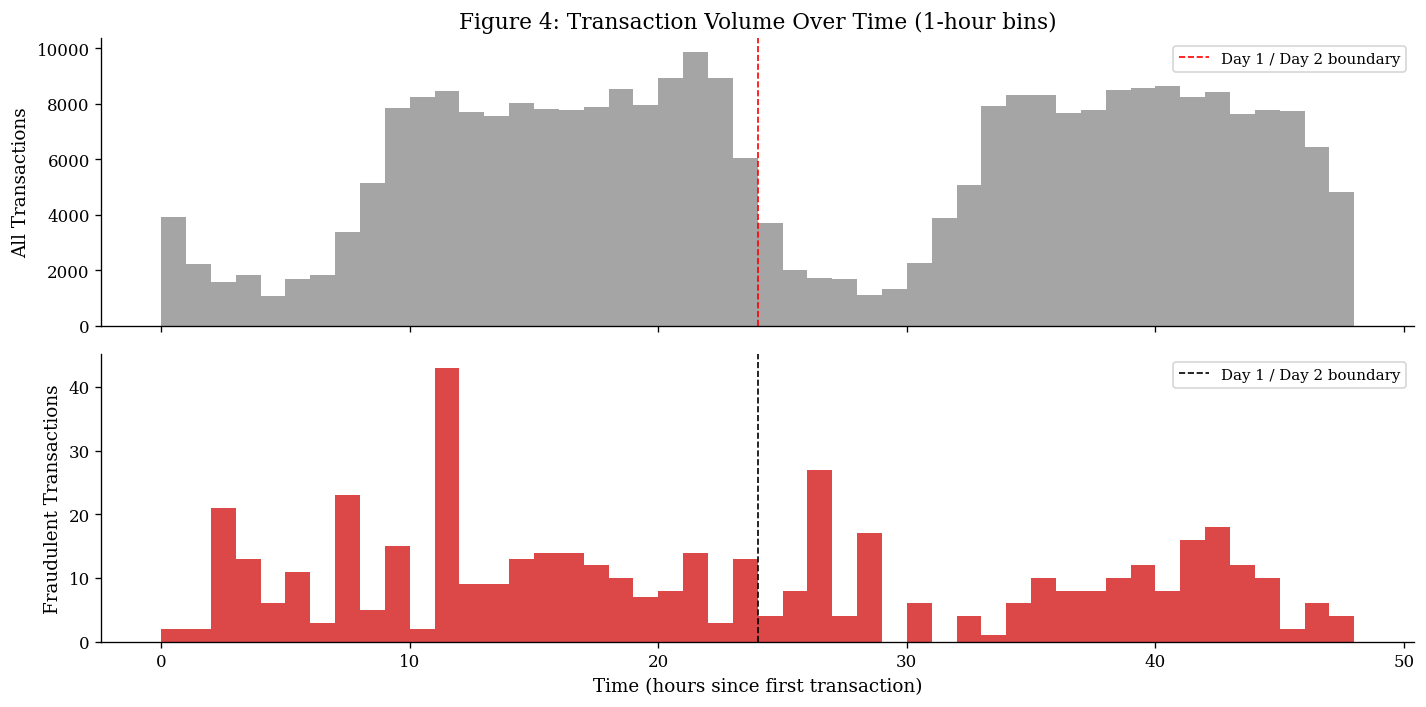

Saved: fig4_temporal_volume.png


In [8]:
# --- Transaction volume over time ---
BIN_HOURS = 1  # 1-hour bins
bins = np.arange(0, df['Time_hours'].max() + BIN_HOURS, BIN_HOURS)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# All transactions
axes[0].hist(df['Time_hours'], bins=bins, color=NEUTRAL_COLOR, alpha=0.7, edgecolor='none')
axes[0].set_ylabel('All Transactions')
axes[0].set_title('Figure 4: Transaction Volume Over Time (1-hour bins)')
axes[0].axvline(24, color='red', linestyle='--', linewidth=1, label='Day 1 / Day 2 boundary')
axes[0].legend(fontsize=9)

# Fraud only
axes[1].hist(fraud['Time_hours'], bins=bins, color=FRAUD_COLOR, alpha=0.85, edgecolor='none')
axes[1].set_ylabel('Fraudulent Transactions')
axes[1].set_xlabel('Time (hours since first transaction)')
axes[1].axvline(24, color='black', linestyle='--', linewidth=1, label='Day 1 / Day 2 boundary')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_temporal_volume.png', bbox_inches='tight')
plt.show()
print('Saved: fig4_temporal_volume.png')

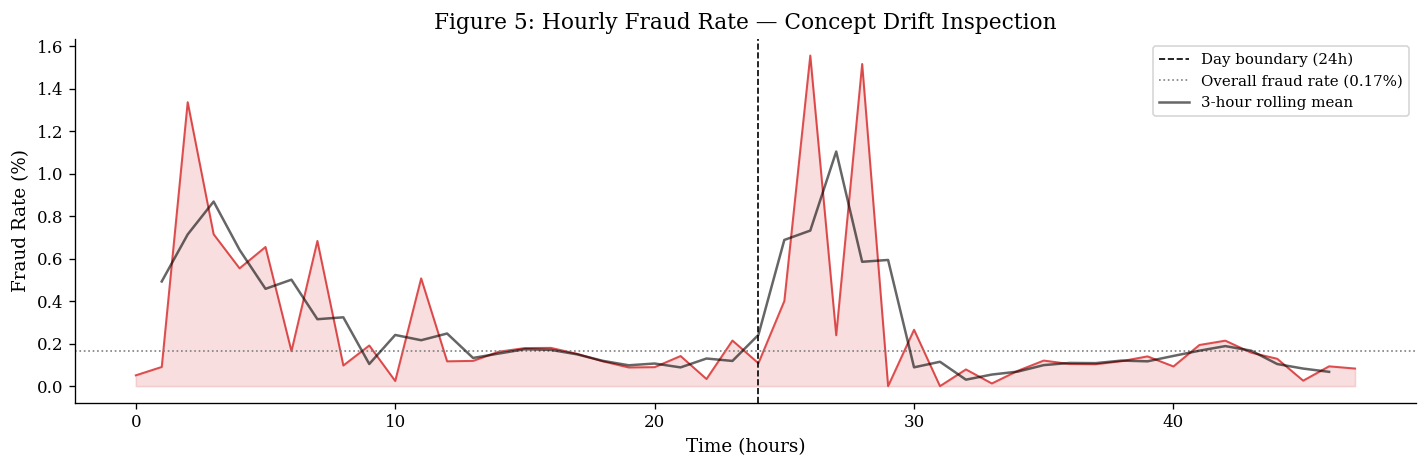

Day 1 fraud rate: 0.1886%
Day 2 fraud rate: 0.1441%
Difference: 0.0445 percentage points

Dissertation note: The 2-day window limits the ability to detect substantial concept drift.
Any observed rate variation may reflect daily patterns (e.g. night-time vs daytime)
rather than genuine long-term fraud pattern evolution (Topal et al., 2025).


In [9]:
# --- Concept drift check: fraud RATE per hour ---
# If concept drift is present, we expect the fraud rate to shift across hours
df['time_bin'] = pd.cut(df['Time_hours'], bins=bins, labels=False)
fraud_rate = df.groupby('time_bin').apply(
    lambda x: x['Class'].sum() / len(x) * 100
).reset_index()
fraud_rate.columns = ['time_bin', 'fraud_rate_pct']
fraud_rate['time_hours'] = fraud_rate['time_bin'] * BIN_HOURS

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fraud_rate['time_hours'], fraud_rate['fraud_rate_pct'],
        color=FRAUD_COLOR, linewidth=1.2, alpha=0.8)
ax.fill_between(fraud_rate['time_hours'], fraud_rate['fraud_rate_pct'],
                alpha=0.15, color=FRAUD_COLOR)
ax.axvline(24, color='black', linestyle='--', linewidth=1, label='Day boundary (24h)')
ax.axhline(pct_fraud, color=NEUTRAL_COLOR, linestyle=':', linewidth=1,
           label=f'Overall fraud rate ({pct_fraud:.2f}%)')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Figure 5: Hourly Fraud Rate — Concept Drift Inspection')
ax.legend(fontsize=9)

# Rolling average to highlight trend
rolling = fraud_rate['fraud_rate_pct'].rolling(window=3, center=True).mean()
ax.plot(fraud_rate['time_hours'], rolling, color='black', linewidth=1.5,
        linestyle='-', label='3-hour rolling mean', alpha=0.6)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_fraud_rate_over_time.png', bbox_inches='tight')
plt.show()

# Dissertation note
day1_rate = df[df['Time_hours'] <= 24]['Class'].mean() * 100
day2_rate = df[df['Time_hours'] > 24]['Class'].mean() * 100
print(f'Day 1 fraud rate: {day1_rate:.4f}%')
print(f'Day 2 fraud rate: {day2_rate:.4f}%')
print(f'Difference: {abs(day1_rate - day2_rate):.4f} percentage points')
print()
print('Dissertation note: The 2-day window limits the ability to detect substantial concept drift.')
print('Any observed rate variation may reflect daily patterns (e.g. night-time vs daytime)')
print('rather than genuine long-term fraud pattern evolution (Topal et al., 2025).')

## 7. PCA Feature Analysis

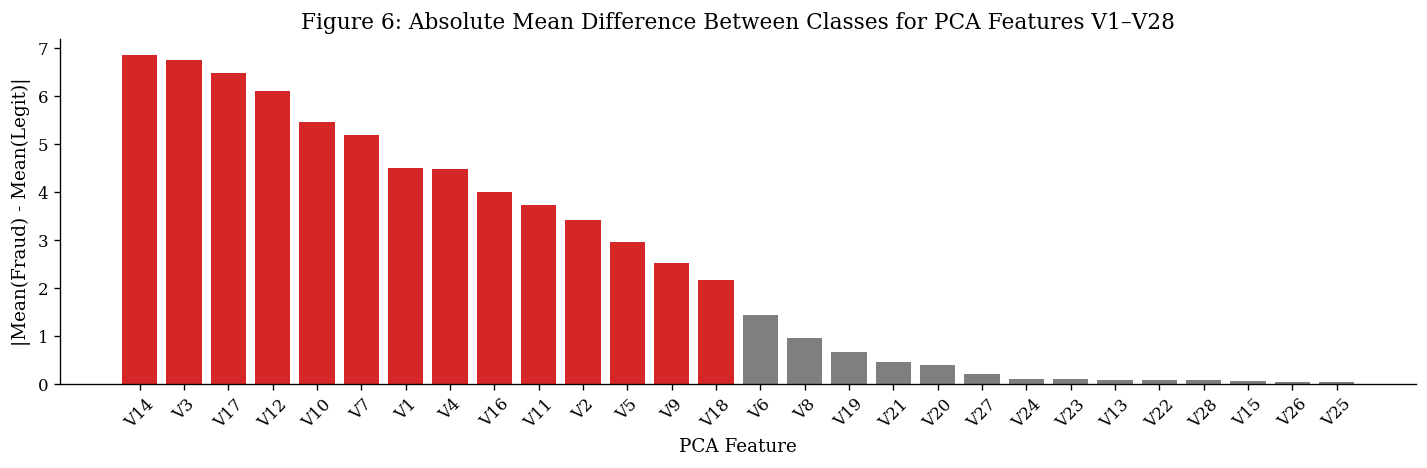

Top 5 most discriminating features by mean difference:
V14    6.847614
V3     6.742452
V17    6.474249
V12    6.112730
V10    5.460937
dtype: float64


In [10]:
# --- Distribution of PCA features V1-V28: mean comparison by class ---
pca_cols = [f'V{i}' for i in range(1, 29)]

fraud_means = fraud[pca_cols].mean()
legit_means = legit[pca_cols].mean()
diff_means  = (fraud_means - legit_means).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
colors = [FRAUD_COLOR if v > diff_means.median() else NEUTRAL_COLOR for v in diff_means.values]
ax.bar(diff_means.index, diff_means.values, color=colors, edgecolor='none')
ax.set_xlabel('PCA Feature')
ax.set_ylabel('|Mean(Fraud) - Mean(Legit)|')
ax.set_title('Figure 6: Absolute Mean Difference Between Classes for PCA Features V1–V28')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig6_pca_mean_diff.png', bbox_inches='tight')
plt.show()

print('Top 5 most discriminating features by mean difference:')
print(diff_means.head())

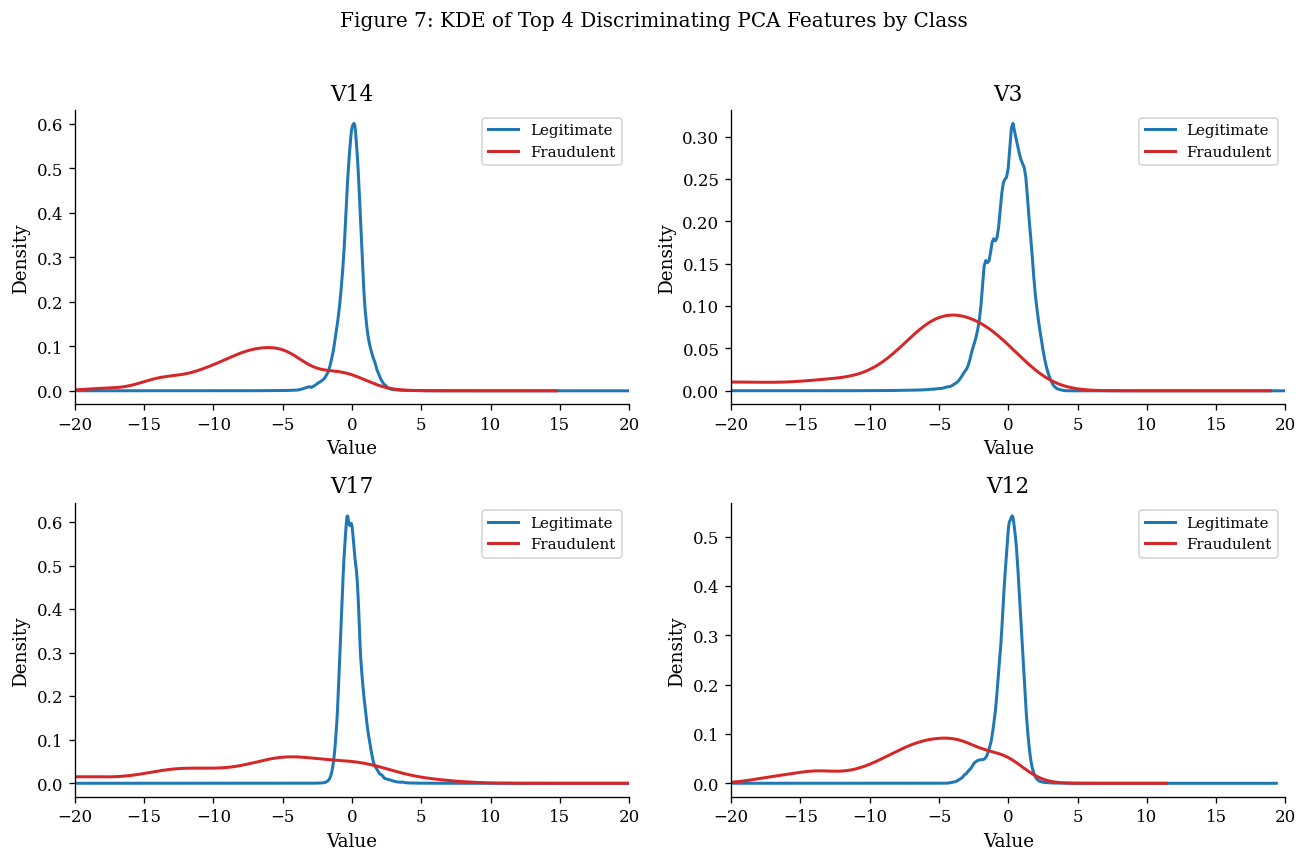

In [11]:
# --- KDE plots for top 4 discriminating features ---
top_features = diff_means.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    legit[feat].plot.kde(ax=axes[i], color=LEGIT_COLOR, label='Legitimate', linewidth=1.8)
    fraud[feat].plot.kde(ax=axes[i], color=FRAUD_COLOR, label='Fraudulent', linewidth=1.8)
    axes[i].set_title(f'{feat}')
    axes[i].set_xlabel('Value')
    axes[i].legend(fontsize=9)
    axes[i].set_xlim([-20, 20])

plt.suptitle('Figure 7: KDE of Top 4 Discriminating PCA Features by Class', y=1.02)
plt.tight_layout()
plt.savefig('fig7_pca_kde.png', bbox_inches='tight')
plt.show()

## 8. Correlation Analysis

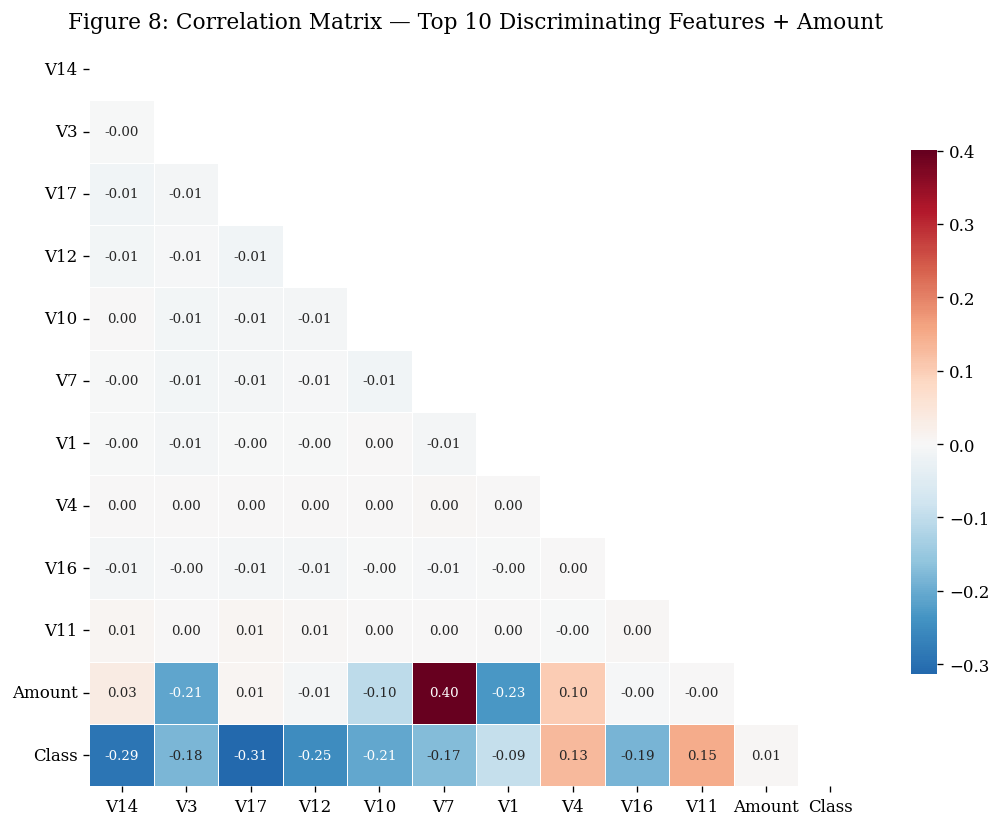

Saved: fig8_correlation_heatmap.png

Note: Low multicollinearity among PCA features — expected from orthogonal decomposition.
Class correlations (top 5):
V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
Name: Class, dtype: float64


In [12]:
# --- Correlation heatmap (fraud class only, top features) ---
top10 = diff_means.head(10).index.tolist() + ['Amount', 'Class']
corr = df[top10].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8})
ax.set_title('Figure 8: Correlation Matrix — Top 10 Discriminating Features + Amount')
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: fig8_correlation_heatmap.png')
print()
print('Note: Low multicollinearity among PCA features — expected from orthogonal decomposition.')
print('Class correlations (top 5):')
print(corr['Class'].drop('Class').abs().sort_values(ascending=False).head())

## 9. Temporal Train-Test Split Construction

=== Temporal Train-Test Split (80/20 Chronological) ===
Split boundary : row 226,980 | Time=145234s (40.3h)

Train set: 226,980 rows (80.0%)
  Fraud  : 399 (0.1758%)
  Legit  : 226,581

Test set : 56,746 rows (20.0%)
  Fraud  : 74 (0.1304%)
  Legit  : 56,672


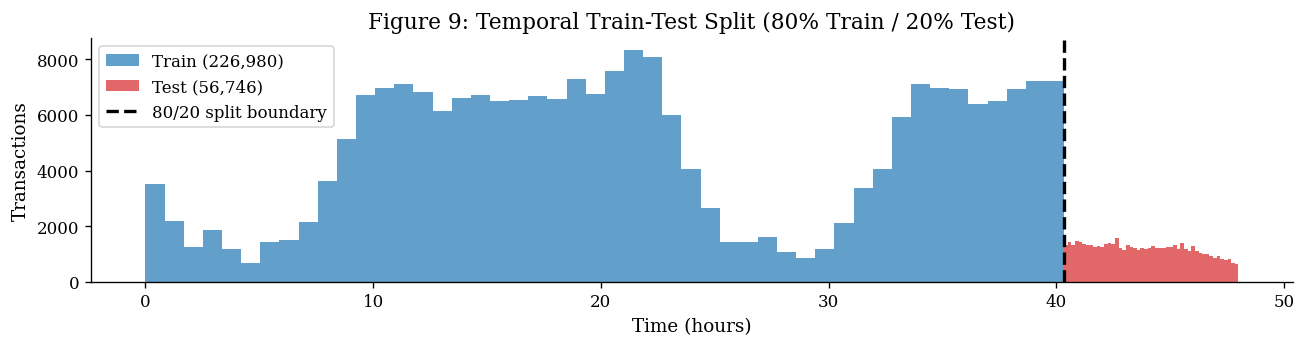

In [13]:
# Sort by Time to ensure chronological order
df_sorted = df.sort_values('Time').reset_index(drop=True)

# Temporal split: 80% train, 20% test
SPLIT_RATIO = 0.80
split_idx = int(len(df_sorted) * SPLIT_RATIO)
split_time = df_sorted.iloc[split_idx]['Time']

train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print('=== Temporal Train-Test Split (80/20 Chronological) ===')
print(f'Split boundary : row {split_idx:,} | Time={split_time:.0f}s ({split_time/3600:.1f}h)')
print()
print(f'Train set: {len(train_df):,} rows ({len(train_df)/len(df_sorted)*100:.1f}%)')
print(f'  Fraud  : {train_df["Class"].sum()} ({train_df["Class"].mean()*100:.4f}%)')
print(f'  Legit  : {(train_df["Class"]==0).sum():,}')
print()
print(f'Test set : {len(test_df):,} rows ({len(test_df)/len(df_sorted)*100:.1f}%)')
print(f'  Fraud  : {test_df["Class"].sum()} ({test_df["Class"].mean()*100:.4f}%)')
print(f'  Legit  : {(test_df["Class"]==0).sum():,}')

# Visualise the split
fig, ax = plt.subplots(figsize=(11, 3))
ax.hist(train_df['Time_hours'] if 'Time_hours' in train_df.columns else train_df['Time']/3600,
        bins=48, color=LEGIT_COLOR, alpha=0.7, label=f'Train ({len(train_df):,})')
ax.hist(test_df['Time_hours'] if 'Time_hours' in test_df.columns else test_df['Time']/3600,
        bins=48, color=FRAUD_COLOR, alpha=0.7, label=f'Test ({len(test_df):,})')
ax.axvline(split_time/3600, color='black', linestyle='--', linewidth=2, label='80/20 split boundary')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Transactions')
ax.set_title('Figure 9: Temporal Train-Test Split (80% Train / 20% Test)')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_temporal_split.png', bbox_inches='tight')
plt.show()

## 10. Train-Test Integrity & Overlap Check
Verifies the temporal split produces no data leakage between train and test sets.

In [14]:
print('=== Train-Test Integrity & Overlap Check ===')

# Drop helper columns before hashing
helper_cols = ['Time_hours', 'log_amount', 'time_bin']
train_check = train_df.drop(columns=[c for c in helper_cols if c in train_df.columns])
test_check  = test_df.drop(columns=[c for c in helper_cols if c in test_df.columns])

# Hash each row for comparison
train_hashes = set(pd.util.hash_pandas_object(train_check, index=False))
test_hashes  = set(pd.util.hash_pandas_object(test_check,  index=False))
overlap      = len(train_hashes & test_hashes)

print(f'Unique row hashes in train : {len(train_hashes):,}')
print(f'Unique row hashes in test  : {len(test_hashes):,}')
print(f'Overlapping rows           : {overlap}')

if overlap == 0:
    print('No overlap detected — temporal split is clean. No data leakage.')
else:
    print(f'WARNING: {overlap} rows appear in both train and test sets!')

# Time boundary check — confirm no future data in training
max_train_time = train_df['Time'].max()
min_test_time  = test_df['Time'].min()
print(f'\nMax Time in train : {max_train_time:.0f}s ({max_train_time/3600:.2f}h)')
print(f'Min Time in test  : {min_test_time:.0f}s ({min_test_time/3600:.2f}h)')

if max_train_time < min_test_time:
    print('Temporal ordering confirmed: all train transactions precede all test transactions.')
else:
    print('WARNING: Train and test time ranges overlap — check split logic.')

=== Train-Test Integrity & Overlap Check ===
Unique row hashes in train : 226,980
Unique row hashes in test  : 56,746
Overlapping rows           : 0
No overlap detected — temporal split is clean. No data leakage.

Max Time in train : 145233s (40.34h)
Min Time in test  : 145234s (40.34h)
Temporal ordering confirmed: all train transactions precede all test transactions.


## 11. Preprocessing Pipeline

In [15]:
# Drop EDA-only helper columns before modelling
drop_cols   = ['Time_hours', 'log_amount', 'time_bin']
train_clean = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_clean  = test_df.drop( columns=[c for c in drop_cols if c in test_df.columns])

FEATURES = [c for c in train_clean.columns if c != 'Class']
TARGET   = 'Class'

X_train = train_clean[FEATURES].copy()
y_train = train_clean[TARGET].copy()
X_test  = test_clean[FEATURES].copy()
y_test  = test_clean[TARGET].copy()

# StandardScaler on Amount and Time ONLY
# V1-V28 are PCA-transformed — already standardised, do NOT rescale
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])  # fit on train only

print('=== Preprocessing Complete ===')
print(f'X_train: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)')
print(f'X_test : {X_test.shape}  | Fraud: {y_test.sum()}  ({y_test.mean()*100:.4f}%)')
print()
print('StandardScaler fitted on training set only — applied to both sets.')
print('V1-V28 left unscaled (already PCA-standardised by construction).')
print()
print('Amount after scaling (train):')
print(X_train['Amount'].describe().round(4))

# Save to CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)
print()
print('Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv')

=== Preprocessing Complete ===
X_train: (226980, 30) | Fraud: 399 (0.1758%)
X_test : (56746, 30)  | Fraud: 74  (0.1304%)

StandardScaler fitted on training set only — applied to both sets.
V1-V28 left unscaled (already PCA-standardised by construction).

Amount after scaling (train):
count    226980.0000
mean         -0.0000
std           1.0000
min          -0.3626
25%          -0.3387
50%          -0.2689
75%          -0.0436
max          78.0218
Name: Amount, dtype: float64

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv


## 12. EDA Summary — Dissertation Write-Up Reference

In [16]:
print('='*65)
print('EDA COMPLETE — KEY FINDINGS FOR DISSERTATION CHAPTER 3')
print('='*65)

print('\n--- Data Quality ---')
print(f'Missing values     : 0 (confirmed clean)')
print(f'Duplicate rows     : {n_duplicates:,}'
      + (' (removed)' if n_duplicates > 0 else ' (none found)'))
print(f'Class labels       : strictly binary [0, 1] confirmed')
print(f'Data types         : all numeric (float64 / int64) confirmed')
print(f'Amount outliers    : {n_outliers:,} above upper fence (€{upper_fence:.2f})')
print(f'Train-test overlap : {overlap} rows (no leakage)')

print('\n--- Class Imbalance ---')
print(f'Total transactions : {n_total:,}')
print(f'Fraudulent         : {n_fraud} ({pct_fraud:.4f}%)')
print(f'Imbalance ratio    : {int(n_legit/n_fraud):,}:1')
print(f'Naive accuracy     : {100-pct_fraud:.2f}% (entirely misleading)')

print('\n--- Amount Distribution ---')
print(f'Fraud median       : €{fraud["Amount"].median():.2f}')
print(f'Legit median       : €{legit["Amount"].median():.2f}')
print(f'Distribution       : right-skewed, normalised via StandardScaler')

print('\n--- Temporal Patterns ---')
print(f'Dataset span       : ~48 hours (September 2013)')
print(f'Day 1 fraud rate   : {day1_rate:.4f}%')
print(f'Day 2 fraud rate   : {day2_rate:.4f}%')
print(f'Difference         : {abs(day1_rate-day2_rate):.4f} pp')
print(f'Concept drift      : Not observed — fraud is bursty (spikes ~hr 10-13, 25-28)')
print(f'Limitation         : 2-day window limits longitudinal drift analysis')

print('\n--- PCA Features ---')
print(f'Top 5 discriminating features: {list(diff_means.head(5).index)}')
print(f'Multicollinearity  : Low (expected from orthogonal PCA decomposition)')

print('\n--- Train-Test Split ---')
print(f'Method             : Temporal 80/20 (chronological)')
print(f'Split boundary     : {split_time/3600:.1f}h')
print(f'Train              : {len(train_df):,} rows | Fraud: {y_train.sum()}')
print(f'Test               : {len(test_df):,} rows  | Fraud: {y_test.sum()}')
print(f'Test fraud rate    : {y_test.mean()*100:.4f}% (lower than train — burst pattern effect)')
print(f'Overlap            : {overlap} rows (confirmed no leakage)')

print('\n--- Figures Saved ---')
for f in ['fig1_class_distribution.png', 'fig2_amount_distribution.png',
          'fig3_amount_boxplot.png', 'fig4_temporal_volume.png',
          'fig5_fraud_rate_over_time.png', 'fig6_pca_mean_diff.png',
          'fig7_pca_kde.png', 'fig8_correlation_heatmap.png',
          'fig9_temporal_split.png']:
    print(f'  {f}')

print('\n--- CSV Files Saved ---')
for f in ['X_train.csv','X_test.csv','y_train.csv','y_test.csv']:
    print(f'  {f}')

EDA COMPLETE — KEY FINDINGS FOR DISSERTATION CHAPTER 3

--- Data Quality ---
Missing values     : 0 (confirmed clean)
Duplicate rows     : 1,081 (removed)
Class labels       : strictly binary [0, 1] confirmed
Data types         : all numeric (float64 / int64) confirmed
Amount outliers    : 31,685 above upper fence (€185.38)
Train-test overlap : 0 rows (no leakage)

--- Class Imbalance ---
Total transactions : 283,726
Fraudulent         : 473 (0.1667%)
Imbalance ratio    : 598:1
Naive accuracy     : 99.83% (entirely misleading)

--- Amount Distribution ---
Fraud median       : €9.82
Legit median       : €22.00
Distribution       : right-skewed, normalised via StandardScaler

--- Temporal Patterns ---
Dataset span       : ~48 hours (September 2013)
Day 1 fraud rate   : 0.1886%
Day 2 fraud rate   : 0.1441%
Difference         : 0.0445 pp
Concept drift      : Not observed — fraud is bursty (spikes ~hr 10-13, 25-28)
Limitation         : 2-day window limits longitudinal drift analysis

--- PC